# Product Category Performance Analysis
This notebook evaluates product category performance to identify top sellers, profitability, and operational efficiency.
We'll analyze revenue patterns, cancellation rates, fulfillment methods, and B2B vs B2C performance to guide product strategy.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter

## 1. Data Preparation
Loading the raw Amazon sales dataset.

In [ ]:
df = pd.read_csv('../data/amazon_sale_report.csv', low_memory=False)

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


## 2. Feature Selection
Selecting relevant columns for category performance analysis and creating a focused dataset.

In [ ]:
# Keep only the relevant columns
columns_to_keep = [
    'Category',
    'Status',
    'Amount',
    'Qty',
    'Fulfilment',
    'B2B',
    'Size'
]

category_df = df[columns_to_keep].copy()

category_df.info()
category_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Category    128975 non-null  str    
 1   Status      128975 non-null  str    
 2   Amount      121180 non-null  float64
 3   Qty         128975 non-null  int64  
 4   Fulfilment  128975 non-null  str    
 5   B2B         128975 non-null  bool   
 6   Size        128975 non-null  str    
dtypes: bool(1), float64(1), int64(1), str(4)
memory usage: 6.0 MB


,Category,Status,Amount,Qty,Fulfilment,B2B,Size
0,Set,Cancelled,647.62,0,Merchant,False,S
1,kurta,Shipped - Delivered to Buyer,406.00,1,Merchant,False,3XL
2,kurta,Shipped,329.00,1,Amazon,True,XL
3,Western Dress,Cancelled,753.33,0,Merchant,False,L
4,Top,Shipped,574.00,1,Amazon,False,3XL


## 3. Data Preprocessing
Cleaning category names, handling missing values, and preparing data for category performance analysis.
- Standardize column names by removing whitespace
- Standardize category name formatting
- Filter out records with missing critical data
- Create status flags for shipped and cancelled orders
- Prepare data for multi-dimensional category analysis

In [ ]:
# Remove whitespace from column names
df.columns = df.columns.str.strip()

# Clean category names
category_df['Category'] = category_df['Category'].str.strip().str.title()

# Remove rows with missing category or amount
category_df.dropna(subset=['Category', 'Amount'], inplace=True)

# Create status flags
shipped_statuses = [
    'Shipped',
    'Shipped - Delivered to Buyer',
    'Shipped - Picked Up',
    'Shipped - Out for Delivery'
]

category_df['IsShipped'] = category_df['Status'].isin(shipped_statuses)
category_df['IsCancelled'] = category_df['Status'] == 'Cancelled'

print(f"Total Records: {len(category_df):,}")
print(f"Shipped Orders: {category_df['IsShipped'].sum():,}")
print(f"Cancelled Orders: {category_df['IsCancelled'].sum():,}")
print(f"\nUnique Categories: {category_df['Category'].nunique()}")
print(f"\nCategory List:")
print(category_df['Category'].value_counts())

Total Records: 121,180
Shipped Orders: 107,365
Cancelled Orders: 10,766

Unique Categories: 9

Category List:
Category
Set              47042
Kurta            46717
Western Dress    14704
Top              10165
Ethnic Dress      1093
Blouse             881
Bottom             420
Saree              155
Dupatta              3
Name: count, dtype: int64


## 4. Category Revenue Performance Analysis
Analyzing which product categories generate the most revenue and their contribution to overall sales.

In [ ]:
# Calculate revenue by category (shipped orders only)
shipped_df = category_df[category_df['IsShipped']].copy()

category_revenue = shipped_df.groupby('Category').agg({
    'Amount': ['sum', 'mean', 'count'],
    'Qty': 'sum'
}).round(2)

category_revenue.columns = ['TotalRevenue', 'AvgOrderValue', 'OrderCount', 'TotalQty']
category_revenue = category_revenue.sort_values('TotalRevenue', ascending=False)
category_revenue['RevenueShare'] = (category_revenue['TotalRevenue'] / category_revenue['TotalRevenue'].sum() * 100).round(2)

print("Category Performance (Shipped Orders):")
print(category_revenue)

Category Performance (Shipped Orders):
               TotalRevenue  AvgOrderValue  OrderCount  TotalQty  RevenueShare
Category                                                                      
Set              34735836.0         834.23       41638     41760         49.86
Kurta            18930644.0         456.72       41449     41628         27.17
Western Dress     9828746.0         764.64       12854     12897         14.11
Top               4795739.0         525.33        9129      9152          6.88
Ethnic Dress       715351.0         722.58         990       993          1.03
Blouse             409494.0         518.35         790       796          0.59
Bottom             132872.0         359.11         370       374          0.19
Saree              113696.0         800.68         142       146          0.16
Dupatta               915.0         305.00           3         3          0.00


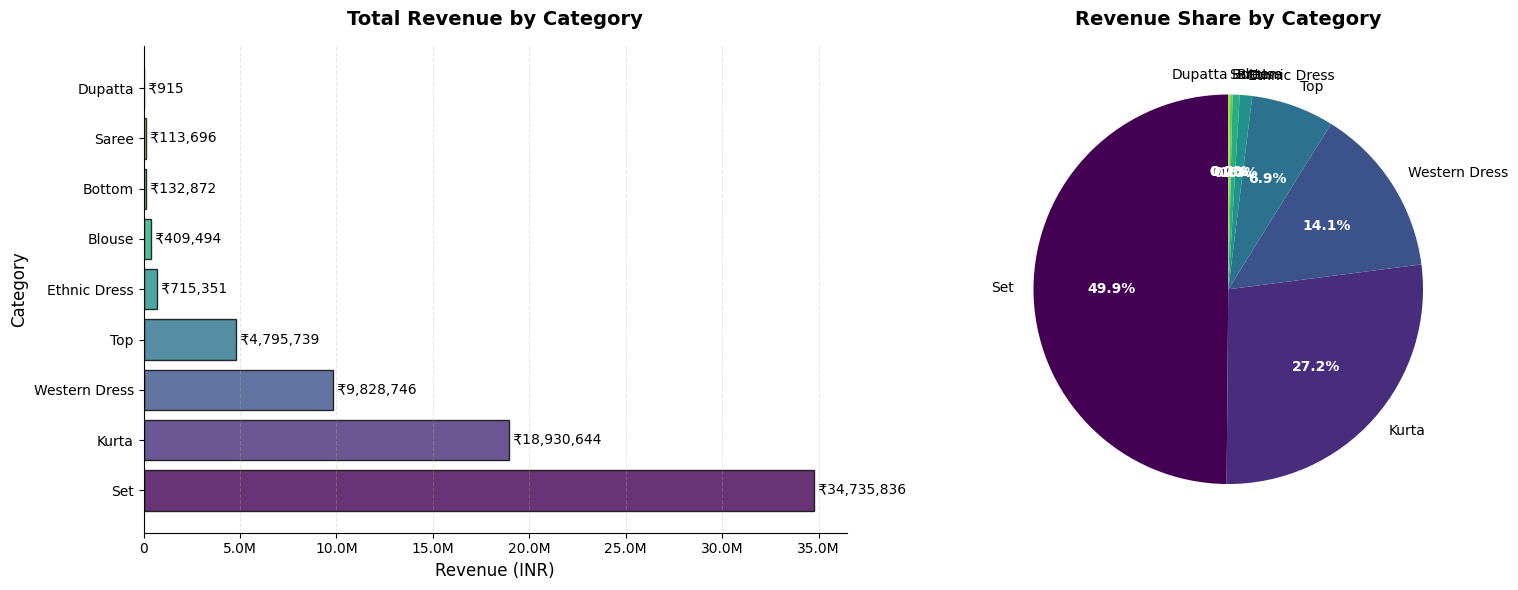

In [ ]:
# Money formatter
def money_format(x, pos):
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x/1_000:.0f}K"
    else:
        return f"{x:.0f}"

formatter = FuncFormatter(money_format)

# Group categories with less than 10% revenue share into "Others"
category_revenue_grouped = category_revenue.copy()

# Identify categories with less than 10% share
small_categories = category_revenue_grouped[category_revenue_grouped['RevenueShare'] < 10]
large_categories = category_revenue_grouped[category_revenue_grouped['RevenueShare'] >= 10]

# Create "Others" row if there are small categories
if len(small_categories) > 0:
    others_row = pd.DataFrame({
        'TotalRevenue': [small_categories['TotalRevenue'].sum()],
        'AvgOrderValue': [small_categories['AvgOrderValue'].mean()],
        'OrderCount': [small_categories['OrderCount'].sum()],
        'TotalQty': [small_categories['TotalQty'].sum()],
        'RevenueShare': [small_categories['RevenueShare'].sum()]
    }, index=['Others'])
    
    category_revenue_grouped = pd.concat([large_categories, others_row])

# Plot revenue by category
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Total revenue bar chart (keep all categories)
categories = category_revenue.index
revenues = category_revenue['TotalRevenue'].values

# Create color palette from viridis colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(categories)))

bars = ax1.barh(categories, revenues, color=colors, edgecolor='black', alpha=0.8)
ax1.set_title('Total Revenue by Category', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Revenue (INR)', fontsize=12)
ax1.set_ylabel('Category', fontsize=12)
ax1.xaxis.set_major_formatter(formatter)

# Add value labels
for i, (cat, val) in enumerate(zip(categories, revenues)):
    ax1.text(val, i, f' ₹{val:,.0f}', va='center', fontsize=10)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, alpha=0.3, linestyle='--', axis='x')

# Revenue share pie chart with "Others" grouping
categories_grouped = category_revenue_grouped.index
colors_grouped = plt.cm.viridis(np.linspace(0, 1, len(categories_grouped)))

wedges, texts, autotexts = ax2.pie(
    category_revenue_grouped['RevenueShare'],
    labels=categories_grouped,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_grouped,
    textprops={'fontsize': 10}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax2.set_title('Revenue Share by Category', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../images/03_category_performance/category_revenue_overview.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Category Cancellation Rate Analysis
Identifying categories with high cancellation rates that may indicate quality or delivery issues.

In [ ]:
# Calculate cancellation rates by category
cancellation_stats = category_df.groupby('Category').agg({
    'IsCancelled': ['sum', 'count']
})

cancellation_stats.columns = ['Cancelled', 'Total']
cancellation_stats['CancellationRate'] = (cancellation_stats['Cancelled'] / cancellation_stats['Total'] * 100).round(2)
cancellation_stats = cancellation_stats.sort_values('CancellationRate', ascending=False)

print("Cancellation Rates by Category:")
print(cancellation_stats)

Cancellation Rates by Category:
               Cancelled  Total  CancellationRate
Category                                         
Bottom                41    420              9.76
Western Dress       1335  14704              9.08
Kurta               4195  46717              8.98
Set                 4199  47042              8.93
Blouse                75    881              8.51
Top                  829  10165              8.16
Saree                 12    155              7.74
Ethnic Dress          80   1093              7.32
Dupatta                0      3              0.00


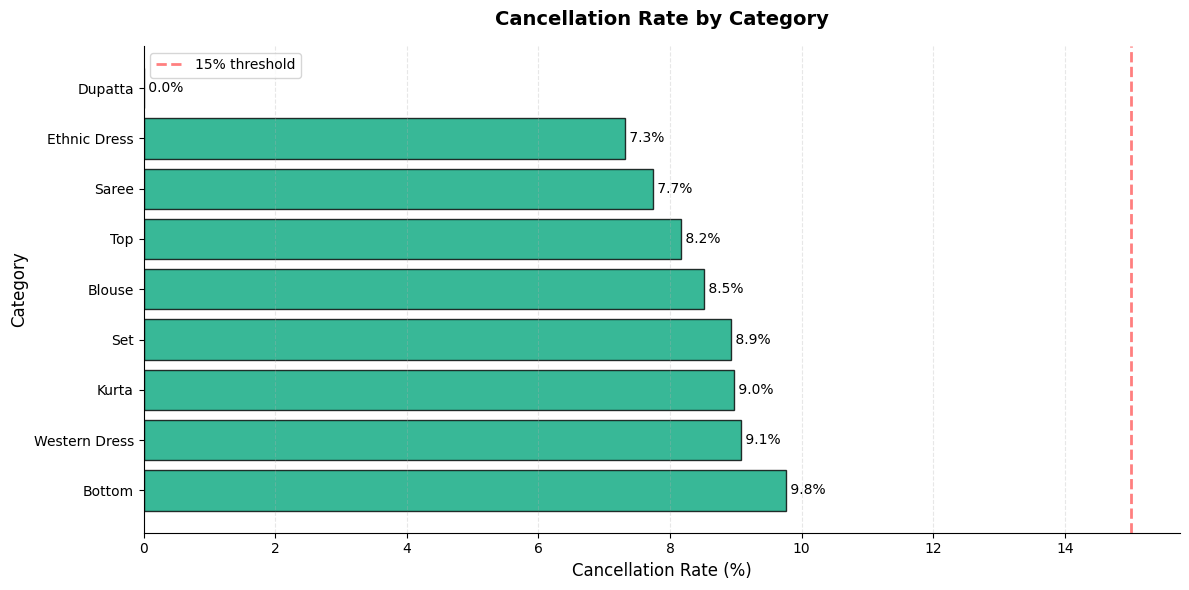

In [ ]:
# Plot cancellation rates
fig, ax = plt.subplots(figsize=(12, 6))

categories = cancellation_stats.index
rates = cancellation_stats['CancellationRate'].values

# Color bars based on rate (red for high, green for low)
colors = ['#C73E1D' if rate > 20 else '#F18F01' if rate > 10 else '#06A77D' for rate in rates]

bars = ax.barh(categories, rates, color=colors, edgecolor='black', alpha=0.8)
ax.set_title('Cancellation Rate by Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Cancellation Rate (%)', fontsize=12)
ax.set_ylabel('Category', fontsize=12)

# Add value labels
for i, (cat, val) in enumerate(zip(categories, rates)):
    ax.text(val, i, f' {val:.1f}%', va='center', fontsize=10)

# Add reference line at 15%
ax.axvline(x=15, color='red', linestyle='--', alpha=0.5, linewidth=2, label='15% threshold')
ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, linestyle='--', axis='x')

plt.tight_layout()
plt.savefig('../images/03_category_performance/category_cancellation_rates.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Fulfillment Method Performance Comparison
Comparing Amazon vs Merchant fulfillment performance across different product categories.

In [ ]:
# Analyze fulfillment by category (shipped orders only)
fulfillment_analysis = shipped_df.groupby(['Category', 'Fulfilment']).agg({
    'Amount': 'sum',
    'Qty': 'sum'
}).reset_index()

# Pivot for easier comparison
fulfillment_pivot = fulfillment_analysis.pivot(index='Category', columns='Fulfilment', values='Amount').fillna(0)

print("Revenue by Category and Fulfillment Method:")
print(fulfillment_pivot)

Revenue by Category and Fulfillment Method:
Fulfilment         Amazon   Merchant
Category                            
Blouse           323361.0    86133.0
Bottom            81386.0    51486.0
Dupatta             915.0        0.0
Ethnic Dress     549448.0   165903.0
Kurta          14068674.0  4861970.0
Saree             94769.0    18927.0
Set            25574413.0  9161423.0
Top             3811430.0   984309.0
Western Dress   5819859.0  4008887.0


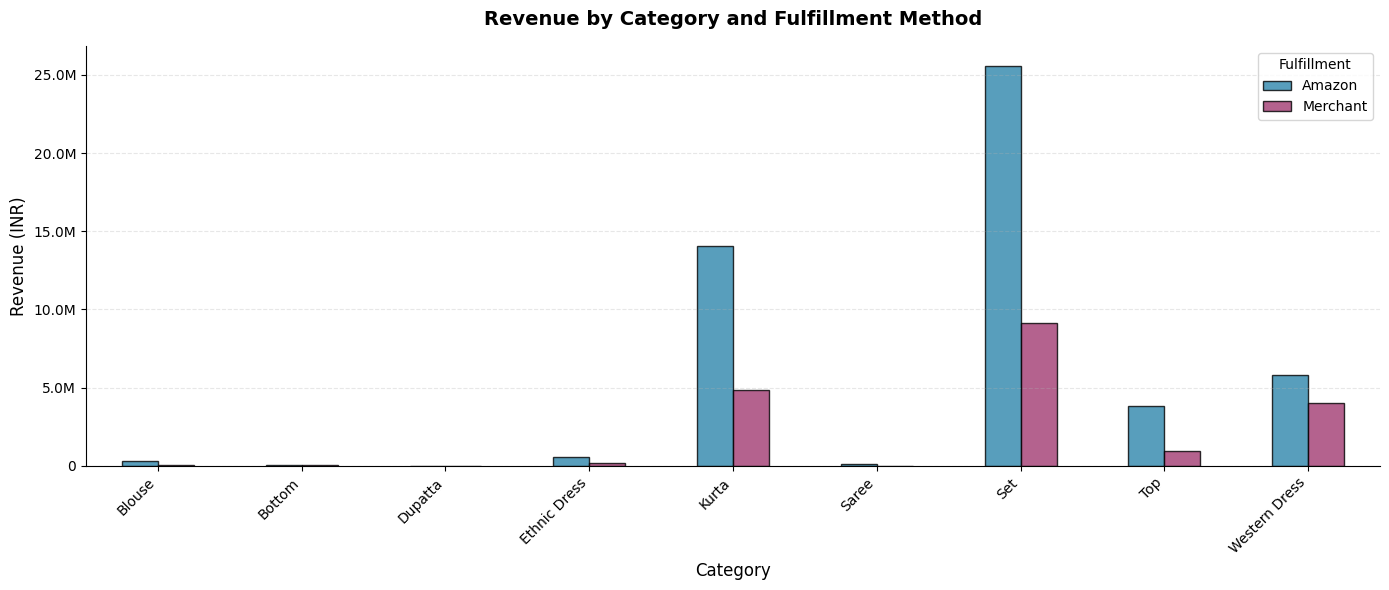

In [ ]:
# Plot fulfillment comparison
fig, ax = plt.subplots(figsize=(14, 6))

fulfillment_pivot.plot(kind='bar', ax=ax, color=['#2E86AB', '#A23B72'], edgecolor='black', alpha=0.8)

ax.set_title('Revenue by Category and Fulfillment Method', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Revenue (INR)', fontsize=12)
ax.yaxis.set_major_formatter(formatter)
ax.legend(title='Fulfillment', fontsize=10)
plt.xticks(rotation=45, ha='right')
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../images/03_category_performance/category_fulfillment_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. B2B vs B2C Sales Pattern Analysis
Understanding business versus consumer sales patterns and performance across product categories.

In [ ]:
# Analyze B2B vs B2C by category (shipped orders only)
b2b_analysis = shipped_df.groupby(['Category', 'B2B']).agg({
    'Amount': 'sum',
    'Qty': 'sum'
}).reset_index()

# Pivot for easier comparison
b2b_pivot = b2b_analysis.pivot(index='Category', columns='B2B', values='Amount').fillna(0)
b2b_pivot.columns = ['B2C', 'B2B']

# Calculate B2B percentage
b2b_pivot['B2B_Percentage'] = (b2b_pivot['B2B'] / (b2b_pivot['B2B'] + b2b_pivot['B2C']) * 100).round(2)
b2b_pivot = b2b_pivot.sort_values('B2B_Percentage', ascending=False)

print("B2B vs B2C Revenue by Category:")
print(b2b_pivot)

B2B vs B2C Revenue by Category:
                      B2C       B2B  B2B_Percentage
Category                                           
Ethnic Dress     704424.0   10927.0            1.53
Saree            112045.0    1651.0            1.45
Set            34456890.0  278946.0            0.80
Western Dress   9751678.0   77068.0            0.78
Kurta          18783762.0  146882.0            0.78
Blouse           406351.0    3143.0            0.77
Top             4765020.0   30719.0            0.64
Bottom           132081.0     791.0            0.60
Dupatta             915.0       0.0            0.00


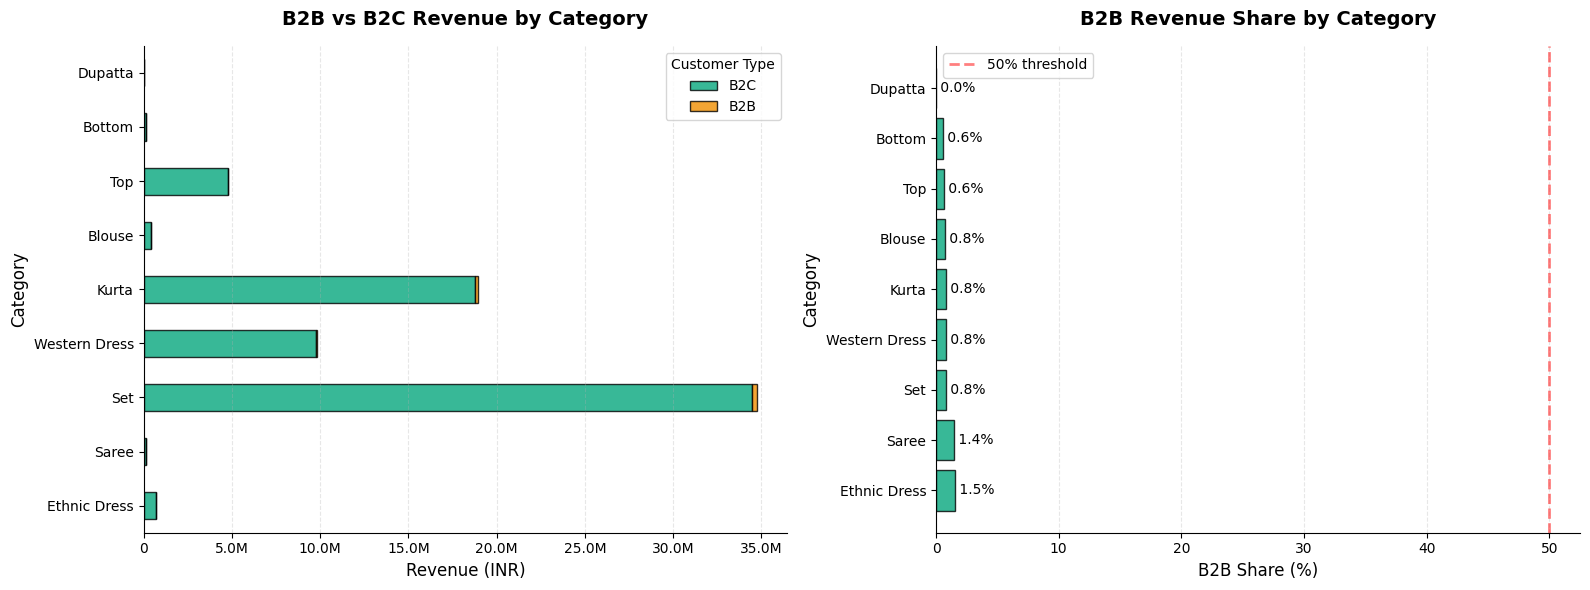

In [ ]:
# Plot B2B vs B2C comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar chart
b2b_pivot[['B2C', 'B2B']].plot(
    kind='barh',
    stacked=True,
    ax=ax1,
    color=['#06A77D', '#F18F01'],
    edgecolor='black',
    alpha=0.8
)

ax1.set_title('B2B vs B2C Revenue by Category', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Revenue (INR)', fontsize=12)
ax1.set_ylabel('Category', fontsize=12)
ax1.xaxis.set_major_formatter(formatter)
ax1.legend(title='Customer Type', fontsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, alpha=0.3, linestyle='--', axis='x')

# B2B percentage
categories = b2b_pivot.index
percentages = b2b_pivot['B2B_Percentage'].values

colors = ['#F18F01' if p > 50 else '#06A77D' for p in percentages]
bars = ax2.barh(categories, percentages, color=colors, edgecolor='black', alpha=0.8)

ax2.set_title('B2B Revenue Share by Category', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('B2B Share (%)', fontsize=12)
ax2.set_ylabel('Category', fontsize=12)

# Add value labels
for i, (cat, val) in enumerate(zip(categories, percentages)):
    ax2.text(val, i, f' {val:.1f}%', va='center', fontsize=10)

ax2.axvline(x=50, color='red', linestyle='--', alpha=0.5, linewidth=2, label='50% threshold')
ax2.legend()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(True, alpha=0.3, linestyle='--', axis='x')

plt.tight_layout()
plt.savefig('../images/03_category_performance/category_b2b_analysis.png', dpi=300, bbox_inches='tight')
plt.show()